# Regression and Mediation Analysis 
### DTI over the Corpus Callosum and Aging, and its relation to proprioceptive performance and interhelmispheric balance
#### Daniela M. Pinzon 
##### 04 2026


### **Step 0. Loading and organizing the dataframe**

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Upload files
tracto_path='/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025'

listsub = ['01', '02', '03', '05', '06', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '19', '20', '21', '22', '23', '24', '25', '26',
             '27', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '41', '46', '47', '48', '49', '50', '51']

# CREATE CSV allsub DTI FILE FOR GIVEN CC and metric
dti_metric_list=['FA']
CCx_list=['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

for dti_metric in dti_metric_list:
    for CCx in CCx_list:
        list_CCx_val = []
        for subj in listsub:
            file_path = os.path.join(tracto_path, f'sub-{subj}_{dti_metric}_tractometry_mergedTOMs.csv')
            if os.path.exists(file_path):
                data_sub = pd.read_csv(file_path, sep=";")
                list_CCx_val.append(data_sub[CCx].values)
            else:
                print(f"File not found: {file_path}")

        # Convert list of arrays → DataFrame
        dfCCx = pd.DataFrame(list_CCx_val)

        # Rename columns seg_2, seg_3, ... up to length
        new_col_names = [f"seg_{i}" for i in range(2, 2 + dfCCx.shape[1])]
        dfCCx.columns = new_col_names

        # Save to CSV
        out_file = f"{CCx}_{dti_metric}.csv"
        #dfCCx.to_csv(out_file, index_label="Index")

        #print(f"Saved {out_file} with shape {dfCCx.shape}")

dfCCx.head()

,seg_2,seg_3,seg_4,seg_5,seg_6,seg_7,seg_8,seg_9,seg_10,seg_11,...,seg_90,seg_91,seg_92,seg_93,seg_94,seg_95,seg_96,seg_97,seg_98,seg_99
0,0.217662,0.210098,0.247803,0.268852,0.290765,0.323112,0.343515,0.357370,0.369495,0.379671,...,0.360924,0.332037,0.314768,0.299466,0.298382,0.308184,0.298445,0.273005,0.262117,0.256813
1,0.253484,0.262070,0.292464,0.332066,0.363638,0.387894,0.380612,0.380712,0.392777,0.405353,...,0.406321,0.379443,0.356917,0.352207,0.348463,0.339861,0.316460,0.295315,0.280481,0.261766
2,0.260242,0.270165,0.298168,0.317146,0.341831,0.349599,0.360562,0.364213,0.387899,0.417723,...,0.401845,0.398161,0.385322,0.370853,0.351907,0.341978,0.327453,0.311015,0.270894,0.284198
3,0.284478,0.273726,0.305177,0.316505,0.333896,0.341914,0.340203,0.352046,0.366992,0.396127,...,0.406781,0.398832,0.383533,0.360845,0.344475,0.325261,0.298865,0.274800,0.256411,0.242831
4,0.299203,0.279968,0.325303,0.330661,0.334002,0.345579,0.356900,0.364836,0.374161,0.378739,...,0.403711,0.402517,0.389317,0.374304,0.378468,0.367895,0.331832,0.293978,0.256532,0.244655


### 1. Pre-processing of the demographic Information

In [3]:
# Install openpyxl if not already installed
#%pip install openpyxl --quiet

# Upload the demographic file
sub_id_file='/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025/Subjects_ID.xlsx'
sub_id = pd.read_excel(sub_id_file)
sub_id

,sub,sex,age,group,JND_P,IHD
0,sub-01,F,25,Y,9.5600,0.534027
1,sub-02,M,27,Y,6.6900,0.570600
2,sub-03,F,28,Y,12.9200,-0.140120
3,sub-05,F,21,Y,1.9500,0.488581
4,sub-06,F,25,Y,2.5400,0.578001
5,sub-08,F,67,O,4.4800,0.419239
6,sub-09,M,73,O,9.6300,0.246470
7,sub-10,F,64,O,7.2700,0.253942
8,sub-11,F,21,Y,1.6200,0.268078
9,sub-12,M,21,Y,3.6800,0.115833


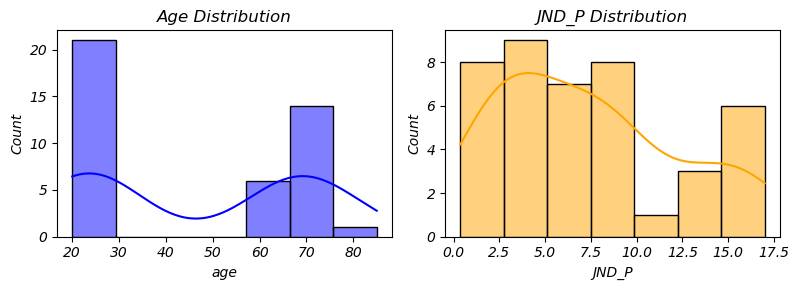

In [4]:
# subplots histogram with KDE for age and JND_P distributions
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
sns.histplot(sub_id['age'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Age Distribution')
sns.histplot(sub_id['JND_P'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('JND_P Distribution')
plt.tight_layout()
plt.show()


In [5]:
CC_path = '/home/daniela/Documents/PROJECTS/Aging_DWI/ML_Analysis'
#sub-46_FA_tractometry_MergedTOMs_last.csv
#CCx_list=['CC_4']

data_frames = []
for CCx in CCx_list:
    for dti_metric in dti_metric_list:
        print(f'Merging data for {CCx} and metric {dti_metric}')
        file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
        CCx_df = pd.read_csv(file_path)
        data_frames = pd.concat([sub_id, CCx_df], axis=1)
        #save merged dataframe
        dfCCx = data_frames
        # eliminnate repeated columns
        dfCCx = dfCCx.loc[:, ~dfCCx.columns.duplicated()]
        #dfCCx.to_csv(CCx +'_'+dti_metric+'.csv', index=False)

dfCCx

Merging data for CC_1 and metric FA
Merging data for CC_2 and metric FA
Merging data for CC_3 and metric FA
Merging data for CC_4 and metric FA
Merging data for CC_5 and metric FA
Merging data for CC_6 and metric FA
Merging data for CC_7 and metric FA


,sub,sex,age,group,JND_P,IHD,Index,seg_2,seg_3,seg_4,...,seg_90,seg_91,seg_92,seg_93,seg_94,seg_95,seg_96,seg_97,seg_98,seg_99
0,sub-01,F,25,Y,9.5600,0.534027,0,0.217662,0.210098,0.247803,...,0.360924,0.332037,0.314768,0.299466,0.298382,0.308184,0.298445,0.273005,0.262117,0.256813
1,sub-02,M,27,Y,6.6900,0.570600,1,0.253484,0.262070,0.292464,...,0.406321,0.379443,0.356917,0.352207,0.348463,0.339861,0.316460,0.295315,0.280481,0.261766
2,sub-03,F,28,Y,12.9200,-0.140120,2,0.260242,0.270165,0.298168,...,0.401845,0.398161,0.385322,0.370853,0.351907,0.341978,0.327453,0.311015,0.270894,0.284198
3,sub-05,F,21,Y,1.9500,0.488581,3,0.284478,0.273726,0.305177,...,0.406781,0.398832,0.383533,0.360845,0.344475,0.325261,0.298865,0.274800,0.256411,0.242831
4,sub-06,F,25,Y,2.5400,0.578001,4,0.299203,0.279968,0.325303,...,0.403711,0.402517,0.389317,0.374304,0.378468,0.367895,0.331832,0.293978,0.256532,0.244655
5,sub-08,F,67,O,4.4800,0.419239,5,0.249114,0.250951,0.267584,...,0.381200,0.377648,0.360250,0.331464,0.297376,0.278327,0.270713,0.255711,0.235702,0.237421
6,sub-09,M,73,O,9.6300,0.246470,6,0.230379,0.236439,0.277582,...,0.395012,0.378646,0.357448,0.361038,0.354933,0.348497,0.333969,0.316496,0.291771,0.259902
7,sub-10,F,64,O,7.2700,0.253942,7,0.247300,0.233605,0.275655,...,0.369204,0.354115,0.336158,0.324867,0.332781,0.344043,0.325135,0.304825,0.279391,0.261053
8,sub-11,F,21,Y,1.6200,0.268078,8,0.258332,0.274093,0.288809,...,0.380472,0.365727,0.343857,0.333253,0.320400,0.311715,0.278089,0.257139,0.227893,0.230166
9,sub-12,M,21,Y,3.6800,0.115833,9,0.322821,0.324031,0.317832,...,0.400494,0.401603,0.379597,0.359640,0.347441,0.335217,0.325998,0.296480,0.256363,0.252924


### 2. Data Visualization 

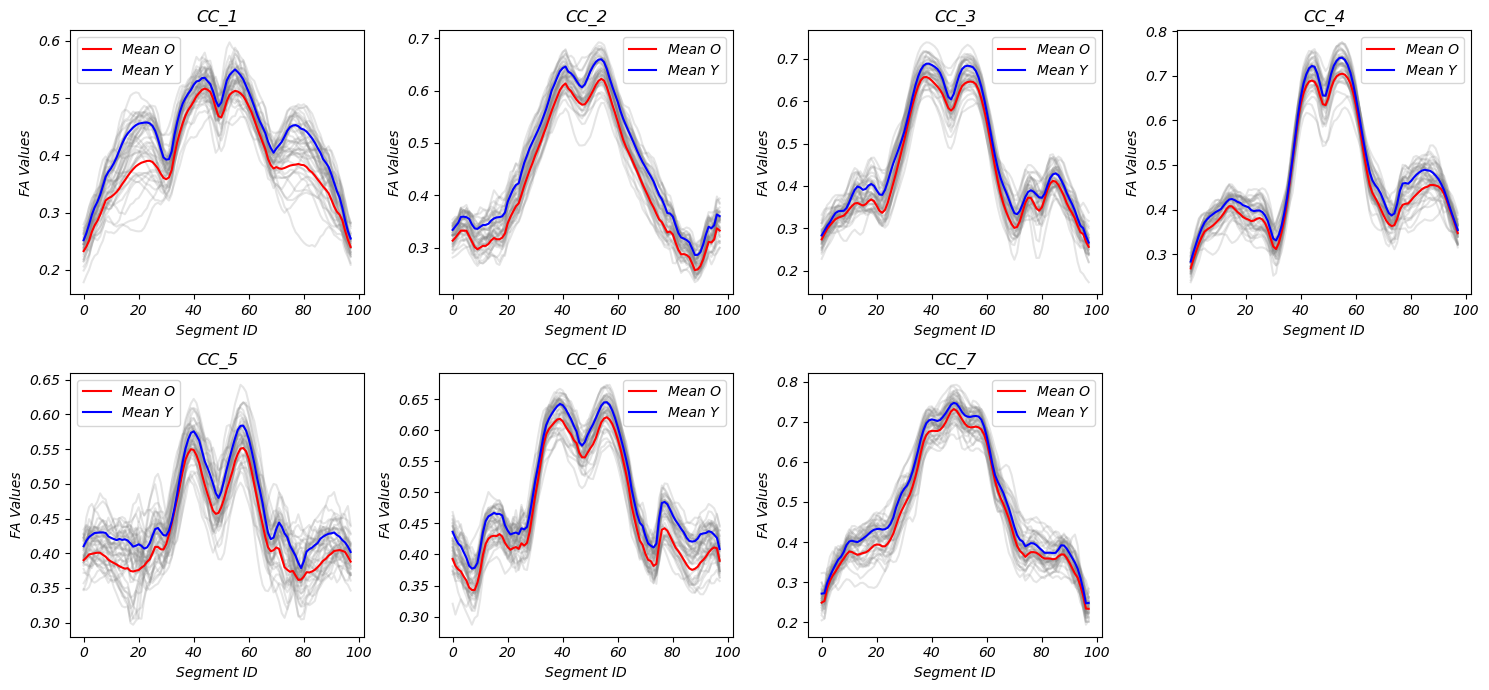

      sub group  age  JND_P sex       IHD
0  sub-01     Y   25   9.56   F  0.534027
1  sub-02     Y   27   6.69   M  0.570600
2  sub-03     Y   28  12.92   F -0.140120
3  sub-05     Y   21   1.95   F  0.488581
4  sub-06     Y   25   2.54   F  0.578001


In [6]:
# Paths and CC list
CC_path = '/home/daniela/Documents/PROJECTS/Aging_DWI/ML_Analysis'
CCx_list = ['CC_1','CC_2','CC_3','CC_4','CC_5','CC_6','CC_7']

# Create subplots (2x4 grid for 7 plots)
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

for i, CCx in enumerate(CCx_list):
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    dfCCx = pd.read_csv(file_path, sep=",")

    #get the subject ID and group information from dfCCx, and drop the remaining columns
    sub_ID = dfCCx[['sub', 'group', 'age', 'JND_P', 'sex', 'IHD']]
    # drop the columns that are not numeric :
    dfCCx = dfCCx.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex','IHD'], axis=1)
    # Select only numeric columns
    feature_cols = dfCCx.select_dtypes(include=['float', 'int']).columns
    
    # X-axis: 98 nodes
    x = range(len(feature_cols))

    # Plot each row as a line
    for idx, row in dfCCx.iterrows():
        axs[i].plot(x, row[feature_cols].values, alpha=0.2, color='gray')
# Plot the mean line
    mean_values = dfCCx[feature_cols].mean()
    #axs[i].plot(x, mean_values.values, color='red', label='Mean FA')
    # mean by 2 group : Young and Old
    dfCCx['group'] = sub_ID['group']
    mean_by_group = dfCCx.groupby('group')[feature_cols].mean()
    for group in mean_by_group.index:
        # color by group
        axs[i].plot(x, mean_by_group.loc[group].values, color='blue' if group == 'Y' else 'red', label=f'Mean {group}')

    axs[i].set_title(f'{CCx}')
    axs[i].set_xlabel('Segment ID')
    axs[i].set_ylabel('FA Values')
    axs[i].legend()
# Remove unused subplot (8th slot)
for j in range(len(CCx_list), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

print(sub_ID.head())


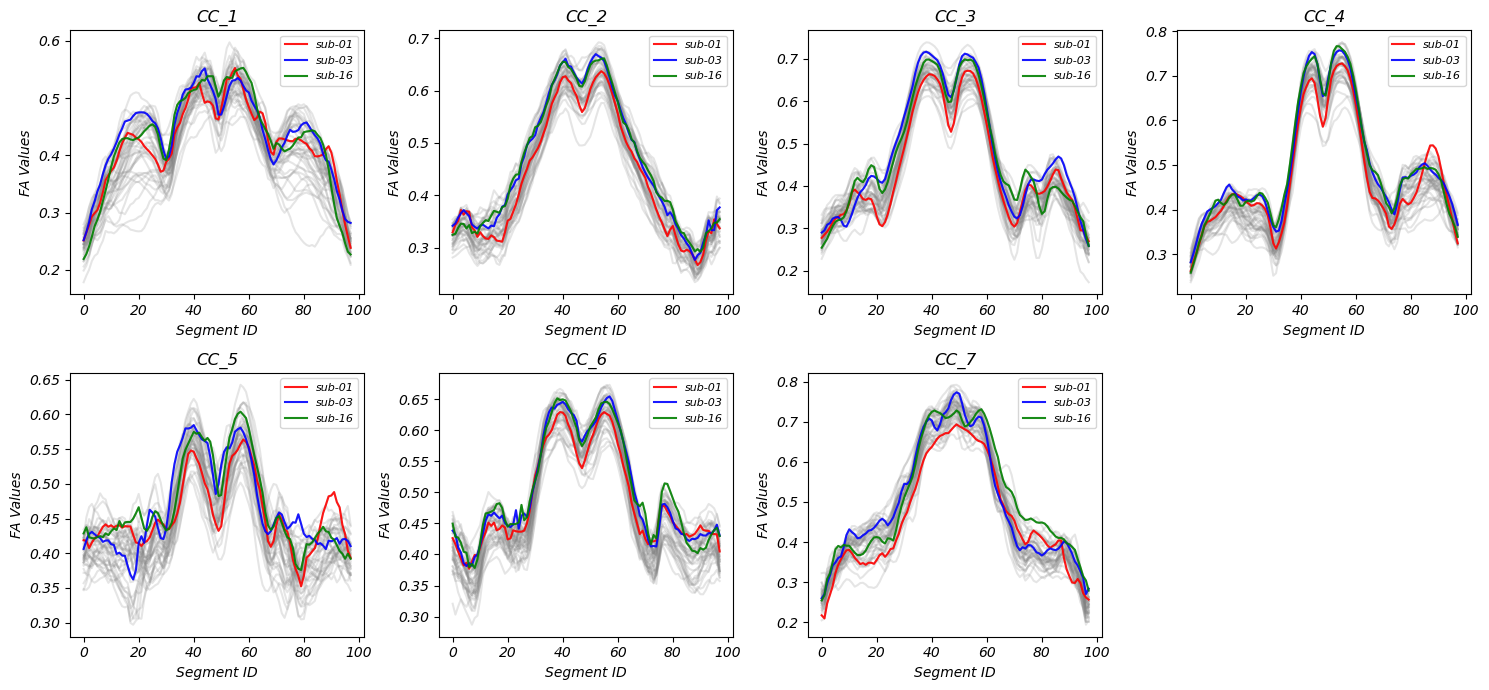

sub-01: JND_P = 9.56, Age = 25
sub-03: JND_P = 12.92, Age = 28
sub-16: JND_P = 9.06, Age = 20


In [7]:
# Create subplots
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

# Subjects to highlight
subject_ids = ['sub-01', 'sub-03', 'sub-16']
subject_colors = {'sub-01': 'red', 'sub-03': 'blue','sub-16': 'green'}

for i, CCx in enumerate(CCx_list):
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    df = pd.read_csv(file_path)

    # Keep a copy with metadata
    meta = df[['sub', 'group', 'age', 'JND_P', 'sex', 'IHD']]
    # Keep only FA values
    df_fa = df.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
    feature_cols = df_fa.select_dtypes(include=['float', 'int']).columns
    x = range(len(feature_cols))

    # Plot all subjects (gray)
    for idx in df_fa.index:
        axs[i].plot(x, df_fa.loc[idx, feature_cols].values,
                    alpha=0.2, color='gray')
    # Plot selected subjects
    for subject_id in subject_ids:
        mask = meta['sub'] == subject_id
        if mask.any():
            row = df_fa[mask].iloc[0]
            axs[i].plot(
                x,
                row[feature_cols].values,
                alpha=0.9,
                linewidth=1.5,
                color=subject_colors[subject_id],
                label=subject_id
            )
    # Formatting
    axs[i].set_title(CCx)
    axs[i].set_xlabel('Segment ID')
    axs[i].set_ylabel('FA Values')

    # Avoid duplicate legends
    handles, labels = axs[i].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[i].legend(by_label.values(), by_label.keys(), fontsize=8)

# Remove empty subplot
for j in range(len(CCx_list), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

# print the JND values and age for the highlighted subjects 
for subject_id in subject_ids:
    mask = meta['sub'] == subject_id
    if mask.any():
        jnd_value = meta[mask]['JND_P'].values[0]
        age_value = meta[mask]['age'].values[0]
        print(f"{subject_id}: JND_P = {jnd_value}, Age = {age_value}")

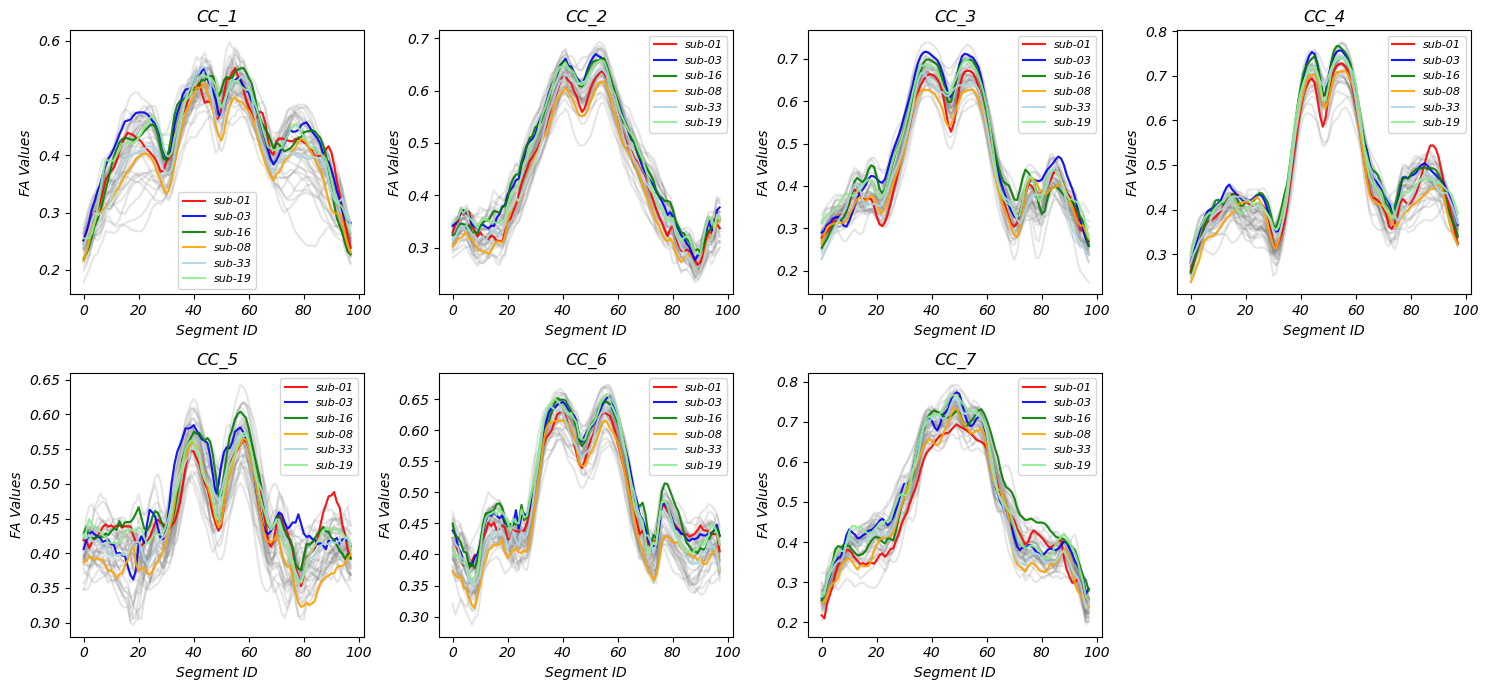

sub-01: JND_P = 9.56, Age = 25
sub-03: JND_P = 12.92, Age = 28
sub-16: JND_P = 9.06, Age = 20
sub-08: JND_P = 4.48, Age = 67
sub-33: JND_P = 4.37, Age = 67
sub-19: JND_P = 6.68, Age = 74


In [8]:
# Odd subjects in the Old group

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 7))
axs = axs.flatten()

# Subjects to highlight
subject_ids = ['sub-01', 'sub-03', 'sub-16','sub-08', 'sub-33', 'sub-19']
subject_colors = {'sub-01': 'red', 'sub-03': 'blue','sub-16': 'green', 'sub-08': 'orange', 'sub-33': 'lightblue','sub-19': 'lightgreen'}

for i, CCx in enumerate(CCx_list):
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    df = pd.read_csv(file_path)

    # Keep a copy with metadata
    meta = df[['sub', 'group', 'age', 'JND_P', 'sex']]
    # Keep only FA values
    df_fa = df.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
    feature_cols = df_fa.select_dtypes(include=['float', 'int']).columns
    x = range(len(feature_cols))

    # Plot all subjects (gray)
    for idx in df_fa.index:
        axs[i].plot(x, df_fa.loc[idx, feature_cols].values,
                    alpha=0.2, color='gray')
    # Plot selected subjects
    for subject_id in subject_ids:
        mask = meta['sub'] == subject_id
        if mask.any():
            row = df_fa[mask].iloc[0]
            axs[i].plot(
                x,
                row[feature_cols].values,
                alpha=0.9,
                linewidth=1.5,
                color=subject_colors[subject_id],
                label=subject_id
            )
    # Formatting
    axs[i].set_title(CCx)
    axs[i].set_xlabel('Segment ID')
    axs[i].set_ylabel('FA Values')

    # Avoid duplicate legends
    handles, labels = axs[i].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axs[i].legend(by_label.values(), by_label.keys(), fontsize=8)

# Remove empty subplot
for j in range(len(CCx_list), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

# print the JND values and age for the highlighted subjects 
for subject_id in subject_ids:
    mask = meta['sub'] == subject_id
    if mask.any():
        jnd_value = meta[mask]['JND_P'].values[0]
        age_value = meta[mask]['age'].values[0]
        print(f"{subject_id}: JND_P = {jnd_value}, Age = {age_value}")

### 3. Simple analysis - global effect
JND∼FAmean​+Age

In [9]:
# Get the mean FA values for each subject for each CC, and save it in a new dataframe   
df_mean_FA = pd.DataFrame()
for CCx in CCx_list:
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    #drop missing values
    #dfCCx = dfCCx.dropna()
    # drop the columns that are not numeric :
    mean_values = dfCCx.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
    
    # get the mean values along the segments for each subject
    mean_values_df = mean_values.mean(axis=1)
    df_mean_FA[CCx] = mean_values_df   

    # get the med-segments for each CC tract, and then save the mean (from 48-5 and 48+5)
    center_CCx = mean_values.iloc[:, 43:53]  # Assuming 98 segments, get the middle ten segments
    center_mean = center_CCx.mean(axis=1)
    df_mean_FA[CCx + '_center'] = center_mean

# dataframe 
df_mean_FA['JND_P'] = sub_ID['JND_P']
df_mean_FA['group'] = sub_ID['group']
df_mean_FA['age'] = sub_ID['age']
df_mean_FA

,CC_1,CC_1_center,CC_2,CC_2_center,CC_3,CC_3_center,CC_4,CC_4_center,CC_5,CC_5_center,CC_6,CC_6_center,CC_7,CC_7_center,JND_P,group,age
0,0.422197,0.492387,0.433916,0.593148,0.442326,0.600152,0.473096,0.657154,0.454889,0.472627,0.488529,0.572409,0.459040,0.678908,9.5600,Y,25
1,0.435293,0.523926,0.460370,0.637466,0.461996,0.655273,0.490447,0.692954,0.465242,0.494818,0.501403,0.599087,0.500431,0.703427,6.6900,Y,27
2,0.438349,0.509818,0.461592,0.638913,0.478353,0.659184,0.499815,0.713948,0.465016,0.534610,0.502382,0.605154,0.494540,0.739482,12.9200,Y,28
3,0.403365,0.482450,0.437396,0.611071,0.445059,0.627508,0.468086,0.665718,0.443992,0.471680,0.484982,0.578450,0.477138,0.729868,1.9500,Y,21
4,0.450210,0.518673,0.479953,0.639970,0.489614,0.657896,0.495008,0.715649,0.460854,0.537240,0.501980,0.623595,0.506974,0.764931,2.5400,Y,25
5,0.390697,0.474799,0.415654,0.572149,0.432174,0.580062,0.459599,0.673997,0.424889,0.478341,0.460773,0.566081,0.457369,0.699350,4.4800,O,67
6,0.401987,0.495506,0.427530,0.594186,0.442259,0.626667,0.461006,0.628343,0.437943,0.463733,0.477700,0.579515,0.484520,0.738491,9.6300,O,73
7,0.410109,0.501930,0.437462,0.591888,0.450372,0.607378,0.489683,0.705092,0.471926,0.535322,0.496140,0.587990,0.475404,0.686323,7.2700,O,64
8,0.412308,0.492906,0.435843,0.603847,0.439962,0.618214,0.472030,0.688955,0.443820,0.497046,0.485233,0.581015,0.482554,0.725155,1.6200,Y,21
9,0.431783,0.528377,0.457623,0.631065,0.449962,0.629377,0.485562,0.701292,0.458856,0.525986,0.501376,0.602865,0.496977,0.753575,3.6800,Y,21


/tmp/ipykernel_128695/1524603946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='group', y=metric, data=df_mean_FA, palette=palette, showfliers=False, width=0.5, boxprops=dict(alpha=0.6))


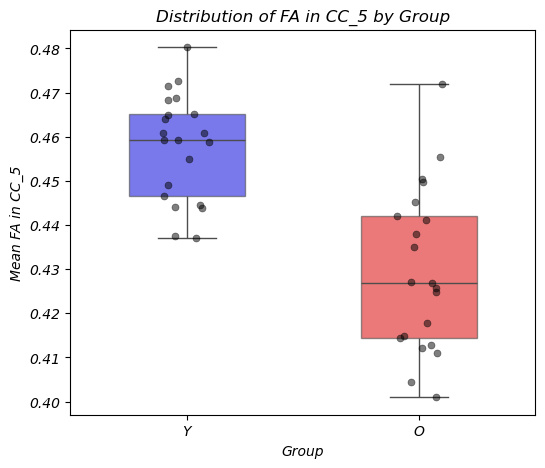

In [10]:
# distribution of FA in CC4 and CC5, using boxplot and scatter plot, with only FA on the x-axis, colored by group
palette = {'Y': 'blue', 'O': 'red'}
metric = 'CC_5'
plt.figure(figsize=(6, 5))
sns.boxplot(x='group', y=metric, data=df_mean_FA, palette=palette, showfliers=False, width=0.5, boxprops=dict(alpha=0.6))
sns.stripplot(x='group', y=metric, data=df_mean_FA, color='black', alpha=0.5, jitter=True, linewidth=0.5)
plt.title(f'Distribution of FA in {metric} by Group')
plt.xlabel('Group')
plt.ylabel(f'Mean FA in {metric}')
plt.show()  


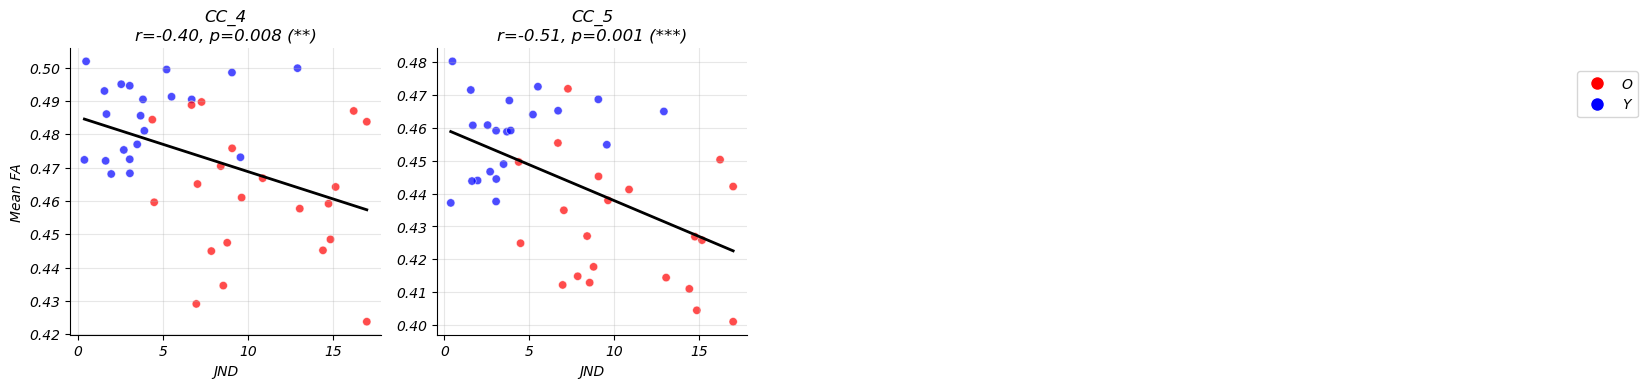

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Create ONE figure
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15, 7))
axs = axs.flatten()

CCx_list = ['CC_4','CC_5']
# Define colors for groups
group_colors = {'O': 'red', 'Y': 'blue'}

for i, CCx in enumerate(CCx_list):
    x = df_mean_FA['JND_P']
    y = df_mean_FA[CCx]
    group = df_mean_FA['group']

    # Compute regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    line = slope * x + intercept

    ax = axs[i]

    # Scatter plot with group colors
    sns.scatterplot(x=x, y=y, hue=group, palette=group_colors, alpha=0.7, ax=ax, legend=False)

    # Regression line (sorted for clean line)
    x_sorted = np.sort(x)
    line_sorted = slope * x_sorted + intercept
    ax.plot(x_sorted, line_sorted, color='black', linewidth=2)

    # Significance label
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "n.s."

    # Title with stats
    ax.set_title(f"{CCx}\nr={r_value:.2f}, p={p_value:.3f} ({sig})")

    # Labels
    ax.set_xlabel("JND")
    if i % 4 == 0:
        ax.set_ylabel("Mean FA")
    else:
        ax.set_ylabel("")

    ax.grid(True, alpha=0.3)

# Remove empty subplot (8th)
for j in range(len(CCx_list), len(axs)):
    fig.delaxes(axs[j])

# Add a legend for the groups
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=group)
           for group, color in group_colors.items()]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.1, 0.9))

sns.despine()
plt.tight_layout()
plt.show()



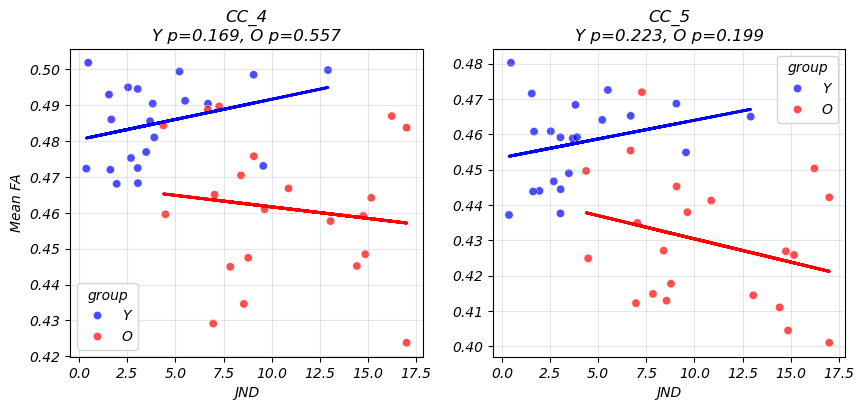

In [46]:
# scatter plot between JND and FA in CC4 and CC5, with separate regression linen per group
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axs = axs.flatten()
CCx_list = ['CC_4','CC_5']
# Define colors for groups
group_colors = {'O': 'red', 'Y': 'blue'}
for i, CCx in enumerate(CCx_list):
    x = df_mean_FA['JND_P']
    y = df_mean_FA[CCx]
    group = df_mean_FA['group']
    
    ax = axs[i]

    # Scatter plot with group colors
    sns.scatterplot(x=x, y=y, hue=group, palette=group_colors, alpha=0.7, ax=ax)

    # Regression line for each group, with p-value for each group
    for grp in group_colors.keys():
        mask = group == grp
        slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])
        line = slope * x[mask] + intercept
        ax.plot(x[mask], line, color=group_colors[grp], linewidth=2)

    # Significance label for each group
    p_values = []
    for grp in group_colors.keys():
        mask = group == grp
        slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])
        p_values.append(p_value)
    # Title with stats for both groups
    ax.set_title(f"{CCx}\nY p={p_values[1]:.3f}, O p={p_values[0]:.3f}")
    # Labels
    ax.set_xlabel("JND")
    if i % 4 == 0:
        ax.set_ylabel("Mean FA")
    else:
        ax.set_ylabel("")

    ax.grid(True, alpha=0.3)

In [12]:
# Regression intra-group Young vs Old
for CCx in CCx_list:    
    for group in df_mean_FA['group'].unique():
        mask = df_mean_FA['group'] == group
        slope, intercept, r_value, p_value, std_err = stats.linregress(df_mean_FA[mask][CCx], df_mean_FA[mask]['JND_P'])
        print(f"{CCx} - {group}: slope={slope:.4f}, intercept={intercept:.4f}, r={r_value:.4f}, p={p_value:.4f}, std_err={std_err:.4f}")


CC_4 - Y: slope=86.3954, intercept=-37.8176, r=0.3118, p=0.1688, std_err=60.3943
CC_4 - O: slope=-28.6970, intercept=23.8283, r=-0.1358, p=0.5574, std_err=48.0448
CC_5 - Y: slope=72.8830, intercept=-29.2741, r=0.2779, p=0.2226, std_err=57.7952
CC_5 - O: slope=-64.8430, intercept=38.4489, r=-0.2920, p=0.1990, std_err=48.7250


4. Linear Mixed Models

FA ~ JND + Age + (1|Subject)

In [13]:
# Get the mean FA values only the segments 50 -5 et +5 
from sklearn.preprocessing import RobustScaler, StandardScaler
scaler = RobustScaler()


df_meanCC_FA = pd.DataFrame()
df_meanCC_FA_scaled = pd.DataFrame()
for CCx in CCx_list:
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    #drop missing values
    dfCCx = dfCCx.dropna()
    # drop the columns that are not numeric :
    mean_values = dfCCx.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
    # select the values from segment seg_45 to seg_55
    #mean_values = mean_values.iloc[:, 43:54]
    mean_values = mean_values.iloc[:, 38:59] # from 50-5 to 50+5
    df_meanCC_FA[CCx] = mean_values.mean(axis=1)

scaled_features = scaler.fit_transform(df_meanCC_FA)

df_meanCC_FA_scaled = pd.DataFrame(scaled_features)

# dataframe 
#df_meanCC_FA_scaled = pd.concat([sub_ID, df_meanCC_FA_scaled], axis=1)
df_meanCC_FA

,CC_4,CC_5
0,0.665628,0.510137
1,0.689853,0.530488
2,0.709053,0.555151
3,0.660893,0.508443
4,0.708776,0.561749
5,0.672706,0.514357
6,0.628825,0.494410
7,0.697490,0.568419
8,0.681769,0.526689
9,0.695861,0.539282


In [14]:
# linear regression for predincting JND, covariate with group, for each CC (column) in the dataframe df_meanCC_FA
import statsmodels.formula.api as smf

for CCx in CCx_list:
    model = smf.ols(formula=f'JND_P ~ {CCx} * group', data=df_mean_FA).fit()
    print(f"Regression results for {CCx} (covariate: group):")
    print(model.summary())
    print("\n\n")

Regression results for CC_4 (covariate: group):
                            OLS Regression Results                            
Dep. Variable:                  JND_P   R-squared:                       0.476
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     11.51
Date:                Sun, 03 May 2026   Prob (F-statistic):           1.65e-05
Time:                        14:06:10   Log-Likelihood:                -112.33
No. Observations:                  42   AIC:                             232.7
Df Residuals:                      38   BIC:                             239.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

# Mediation model for this measure

In [15]:
# standar scaler pour df_meanCC_FA
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
#apply the scaler to the dataframe df_meanCC_FA, and save the result in a new dataframe df_meanCC_FA_scaled
df_meanCC_FA_scaled = pd.DataFrame()
for CCx in CCx_list:
    scaled_features = scaler.fit_transform(df_mean_FA[CCx].values.reshape(-1, 1))
    scaled_features = scaled_features.flatten()  # Flatten to 1D array
    df_meanCC_FA_scaled[CCx] = scaled_features

df_meanCC_FA_scaled = pd.concat([sub_ID, df_meanCC_FA_scaled], axis=1)
df_meanCC_FA_scaled

,sub,group,age,JND_P,sex,IHD,CC_4,CC_5
0,sub-01,Y,25,9.5600,F,0.534027,-0.039794,0.300371
1,sub-02,Y,27,6.6900,M,0.570600,0.587698,0.609856
2,sub-03,Y,28,12.9200,F,-0.140120,0.926500,0.603092
3,sub-05,Y,21,1.9500,F,0.488581,-0.221011,-0.025384
4,sub-06,Y,25,2.5400,F,0.578001,0.752677,0.478683
5,sub-08,O,67,4.4800,F,0.419239,-0.527950,-0.596430
6,sub-09,O,73,9.6300,M,0.246470,-0.477060,-0.206202
7,sub-10,O,64,7.2700,F,0.253942,0.560096,0.809648
8,sub-11,Y,21,1.6200,F,0.268078,-0.078342,-0.030517
9,sub-12,Y,21,3.6800,M,0.115833,0.411044,0.418957


In [16]:
import statsmodels.api as sm
from pingouin import mediation_analysis
# here I use the FA mean of the whole CC tracts to perform the mediation analysis between age and JND_P, with mean FA as mediator
df_CCs = df_meanCC_FA_scaled.copy()

for CCx in CCx_list:
    data = pd.DataFrame({
        'age': df_CCs["age"],
        'JND': df_CCs["JND_P"],
        'IHD': df_CCs["IHD"],
        'meanFA': df_CCs[CCx],
    })
    # Mediation analysis
    mediation_results = mediation_analysis(data=data, x='meanFA', y='JND', m='age', seed=42)
    print(f"Results for {CCx}:")
    print(mediation_results)
    print("\n")


Results for CC_4:
       path       coef        se          pval      CI2.5     CI97.5  sig
0   age ~ X -19.688497  4.159170  2.754609e-05 -28.094494 -11.282500  Yes
1   Y ~ age   0.145284  0.023485  2.585873e-07   0.097819   0.192748  Yes
2     Total  -2.757606  0.987420  7.979097e-03  -4.753256  -0.761957  Yes
3    Direct   0.160404  0.975784  8.702771e-01  -1.813306   2.134115   No
4  Indirect  -2.918011  0.865415  0.000000e+00  -5.010993  -1.531400  Yes


Results for CC_5:
       path       coef        se          pval      CI2.5     CI97.5  sig
0   age ~ X -25.833018  4.308333  4.787152e-07 -34.540483 -17.125552  Yes
1   Y ~ age   0.145284  0.023485  2.585873e-07   0.097819   0.192748  Yes
2     Total  -3.973790  1.061472  5.705135e-04  -6.119104  -1.828476  Yes
3    Direct  -0.419023  1.228741  7.349201e-01  -2.904386   2.066340   No
4  Indirect  -3.554767  1.112514  0.000000e+00  -6.297162  -1.824141  Yes




## Mediation model for Age, JND and IHD

In [17]:

mediation_results = mediation_analysis(data=data, x='IHD', y='JND', m='age', seed=42)
print(f"Results for Mediation model x='IHD', y='JND', m='age':")
print(mediation_results)
print("\n")

Results for Mediation model x='IHD', y='JND', m='age':
       path       coef        se      pval      CI2.5     CI97.5  sig
0   age ~ X -38.651109  7.665510  0.000015 -54.229299 -23.072920  Yes
1   Y ~ age   0.131859  0.026551  0.000019   0.077901   0.185818  Yes
2     Total  -6.193027  1.766102  0.001297  -9.782179  -2.603875  Yes
3    Direct  -1.916441  2.078769  0.363266  -6.145729   2.312847   No
4  Indirect  -4.276586  1.799447  0.004000  -8.506421  -1.668113  Yes




In [18]:
# same anakysis but with C. Landelle data
aging_path = "/home/daniela/Documents/PROJECTS/Aging_DWI/Data_Sub"
aging_file_path = os.path.join(aging_path, "ForDiffusionAnalysis_original.xlsx")
aging_data = pd.read_excel(aging_file_path)
# make sure that first row is the header
aging_data.columns = aging_data.iloc[0]
aging_data = aging_data.drop(0).reset_index(drop=True)
# eliminate the last column that is empty
aging_data = aging_data.iloc[:, :-1]
aging_data = aging_data.dropna()
# convert the columns: 'Age', 'JND_P', 'IHD_P' to numeric
aging_data['Age'] = pd.to_numeric(aging_data['Age'], errors='coerce')
aging_data['JND_P'] = pd.to_numeric(aging_data['JND_P'], errors='coerce')
aging_data['JND_T'] = pd.to_numeric(aging_data['JND_T'], errors='coerce')
aging_data['IHD_P'] = pd.to_numeric(aging_data['IHD_P'], errors='coerce')
aging_data

,sub,Age,Sex,Group,JND_P,JND_T,IHD_P
0,S1,25,F,Young,9.56,4.210,0.534027
1,S2,27,H,Young,6.69,11.620,0.570600
2,S3,28,F,Young,12.92,3.790,-0.140120
3,S4,71,F,Old,3.13,4.110,-0.057098
4,S5,21,F,Young,1.95,1.280,0.488581
5,S6,25,F,Young,2.54,2.220,0.578001
6,S8,67,F,Old,4.48,5.080,0.419239
7,S9,73,H,Old,9.63,5.840,0.246470
8,S10,64,F,Old,7.27,5.500,0.253942
9,S11,21,F,Young,1.62,2.550,0.268078


In [19]:
# mediation analysis
aging_data = pd.DataFrame({
    'age': aging_data["Age"],
    'JND_P': aging_data["JND_P"],
    'JND_T': aging_data["JND_T"],
    'IHD': aging_data["IHD_P"],

})
mediation_results = mediation_analysis(data=aging_data, x='IHD', y='JND_T', m='age', seed=42)
print(f"Results for Mediation model x='IHD', y='JND_T', m='age':")
print(mediation_results)
print("\n")

Results for Mediation model x='IHD', y='JND_T', m='age':
       path       coef        se      pval      CI2.5     CI97.5  sig
0   age ~ X -38.859043  7.644141  0.000011 -54.347544 -23.370542  Yes
1   Y ~ age   0.083817  0.023347  0.000955   0.036511   0.131123  Yes
2     Total  -2.966554  1.568751  0.066470  -6.145146   0.212037   No
3    Direct   0.493399  1.867422  0.793122  -3.293909   4.280706   No
4  Indirect  -3.459953  1.036722  0.000000  -6.041905  -1.983463  Yes




# Running Window analysis 


In [20]:
df_window_meanCC_FA = pd.DataFrame()
CClist= ['CC_5']
#CClist= ['CC_1']

for CCx in CClist:
    file_path = os.path.join(CC_path, f'{CCx}_FA.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    dfCCx = dfCCx.dropna()
    # drop the columns that are not numeric :
    mean_values = dfCCx.drop(['Index', 'sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)

    scaler = RobustScaler()
    scaled_features = scaler.fit_transform(mean_values)
    mean_values = pd.DataFrame(scaled_features, columns=mean_values.columns)

    # select the values from segment in windows of 10: from 0 to 5, then from 3 to 8, etc.
    # so it is a running window of 6 segments, with a step of 3 segments
    # then each window will be meaned and saved in a new dataframe df_window_meanCC_FA, for a mediation analysis with age and JND_P
    for start in range(0, mean_values.shape[1] - 5, 3):
        window_mean = mean_values.iloc[:, start:start+5].mean(axis=1)
        df_window_meanCC_FA[f'{CCx}_window_{start}'] = window_mean

        # Mediation analysis for each window
        data = pd.DataFrame({
            'age': sub_id['age'],
            'JND': sub_id['JND_P'],
            'IHD' : sub_id['IHD'],
            'meanFA_window': window_mean
        })  
        mediation_results = mediation_analysis(data=data, x='age', y='JND', m='meanFA_window', seed=42)
        print(f"Results for {CCx} window {start}-{start+5}:")
        print(mediation_results)
        print("\n")



Results for CC_5 window 0-5:
                path      coef        se      pval     CI2.5    CI97.5  sig
0  meanFA_window ~ X -0.014435  0.004508  0.002959 -0.023597 -0.005273  Yes
1  Y ~ meanFA_window -2.243613  1.097414  0.048714 -4.473827 -0.013399  Yes
2              Total  0.131859  0.026551  0.000019  0.077901  0.185818  Yes
3             Direct  0.129467  0.030734  0.000183  0.066938  0.191996  Yes
4           Indirect  0.002393  0.016025  0.924000 -0.023301  0.040404   No


Results for CC_5 window 3-8:
                path      coef        se      pval     CI2.5    CI97.5  sig
0  meanFA_window ~ X -0.017218  0.004969  0.001453 -0.027316 -0.007120  Yes
1  Y ~ meanFA_window -2.095302  0.970417  0.037982 -4.067426 -0.123179  Yes
2              Total  0.131859  0.026551  0.000019  0.077901  0.185818  Yes
3             Direct  0.129610  0.031341  0.000229  0.065846  0.193374  Yes
4           Indirect  0.002249  0.015170  0.880000 -0.022299  0.037560   No


Results for CC_5 window 6-

# OTHER DTI MEASURES

In [21]:
import os
import pandas as pd
import numpy as np

# Define paths and lists
tracto_path = '/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025/'
listsub = ['01', '02', '03', '05', '06', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '19', '20', '21', '22', '23', '24', '25', '26',
           '27', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '41', '46', '47', '48', '49', '50', '51']

dti_metric_list = ['MD', 'AD', 'RD']
CCx_list = ['CC_4', 'CC_5']
out_path = '/home/daniela/Documents/PROJECTS/Aging_DWI/ML_Analysis'


for dti_metric in dti_metric_list:
    for CCx in CCx_list:
        list_CCx_val = []
        for subj in listsub:
            file_path = os.path.join(tracto_path, dti_metric, f'sub-{subj}_{dti_metric}_tractometry_MergedTOMs_last.csv')
            if os.path.exists(file_path):
                data_sub = pd.read_csv(file_path, sep=";")
                list_CCx_val.append(data_sub[CCx].values)
            else:
                print(f"File not found: {file_path}")

        # Convert list of arrays → DataFrame
        dfCCx = pd.DataFrame(list_CCx_val)

        # Rename columns seg_2, seg_3, ... up to length
        new_col_names = [f"seg_{i}" for i in range(2, 2 + dfCCx.shape[1])]
        dfCCx.columns = new_col_names

        # Save to CSV
        out_file = f"{CCx}_{dti_metric}.csv"
        #dfCCx.to_csv(os.path.join(out_path, out_file), index_label="Index")

        #print(f"Saved {out_file} with shape {dfCCx.shape}")

        print(f'Merging data for {CCx} and metric {dti_metric}')
        data_frames = pd.concat([sub_id, dfCCx], axis=1)
        #eliminnate repeated columns
        data_frames = data_frames.loc[:,~data_frames.columns.duplicated()]

        #data_frames.to_csv(os.path.join(out_path, CCx +'_'+dti_metric+'.csv'), index=False)

data_frames



Merging data for CC_4 and metric MD
Merging data for CC_5 and metric MD
Merging data for CC_4 and metric AD
Merging data for CC_5 and metric AD
Merging data for CC_4 and metric RD
Merging data for CC_5 and metric RD


,sub,sex,age,group,JND_P,IHD,seg_2,seg_3,seg_4,seg_5,...,seg_90,seg_91,seg_92,seg_93,seg_94,seg_95,seg_96,seg_97,seg_98,seg_99
0,sub-01,F,25,Y,9.5600,0.534027,0.000467,0.000466,0.000474,0.000469,...,0.000449,0.000442,0.000442,0.000439,0.000445,0.000446,0.000457,0.000460,0.000471,0.000476
1,sub-02,M,27,Y,6.6900,0.570600,0.000471,0.000471,0.000464,0.000454,...,0.000437,0.000432,0.000430,0.000429,0.000429,0.000426,0.000425,0.000420,0.000416,0.000442
2,sub-03,F,28,Y,12.9200,-0.140120,0.000460,0.000453,0.000447,0.000444,...,0.000458,0.000452,0.000453,0.000452,0.000451,0.000456,0.000453,0.000454,0.000458,0.000465
3,sub-05,F,21,Y,1.9500,0.488581,0.000481,0.000465,0.000462,0.000455,...,0.000441,0.000440,0.000442,0.000442,0.000444,0.000447,0.000451,0.000450,0.000454,0.000458
4,sub-06,F,25,Y,2.5400,0.578001,0.000460,0.000456,0.000456,0.000451,...,0.000444,0.000438,0.000439,0.000432,0.000433,0.000435,0.000428,0.000430,0.000441,0.000447
5,sub-08,F,67,O,4.4800,0.419239,0.000476,0.000476,0.000474,0.000477,...,0.000487,0.000489,0.000492,0.000498,0.000491,0.000490,0.000490,0.000485,0.000483,0.000478
6,sub-09,M,73,O,9.6300,0.246470,0.000505,0.000489,0.000478,0.000476,...,0.000465,0.000459,0.000462,0.000465,0.000462,0.000463,0.000461,0.000468,0.000470,0.000472
7,sub-10,F,64,O,7.2700,0.253942,0.000472,0.000469,0.000473,0.000475,...,0.000442,0.000441,0.000439,0.000436,0.000445,0.000446,0.000455,0.000451,0.000460,0.000468
8,sub-11,F,21,Y,1.6200,0.268078,0.000484,0.000483,0.000491,0.000495,...,0.000454,0.000461,0.000471,0.000475,0.000483,0.000489,0.000493,0.000498,0.000499,0.000495
9,sub-12,M,21,Y,3.6800,0.115833,0.000446,0.000443,0.000443,0.000445,...,0.000448,0.000449,0.000445,0.000442,0.000445,0.000445,0.000441,0.000441,0.000443,0.000449


In [22]:
# Get the mean FA values only the segments 50 -5 et +5 
out_path = '/home/daniela/Documents/PROJECTS/Aging_DWI/ML_Analysis/'
dti_metric = 'MD'
CCx_list = ['CC_5']

df_meanCC_DTI = pd.DataFrame()
for CCx in CCx_list:
    file_path = os.path.join(out_path, f'{CCx}_{dti_metric}.csv')
    dfCCx = pd.read_csv(file_path, sep=",")
    #drop missing values
    dfCCx = dfCCx.dropna()
    # drop the columns that are not numeric :
    mean_values = dfCCx.drop(['sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
    
    # select the values from segment seg_45 to seg_55
    #mean_values = mean_values.iloc[:, 43:54]
    mean_values = mean_values.iloc[:, 84:94] 
    df_meanCC_DTI[CCx] = mean_values.mean(axis=1)
    df_meanCC_DTI = pd.concat([sub_id, df_meanCC_DTI], axis=1)
    df_meanCC_DTI = df_meanCC_DTI.loc[:,~df_meanCC_DTI.columns.duplicated()]

df_meanCC_DTI


,sub,sex,age,group,JND_P,IHD,CC_5
0,sub-01,F,25,Y,9.5600,0.534027,0.000623
1,sub-02,M,27,Y,6.6900,0.570600,0.000580
2,sub-03,F,28,Y,12.9200,-0.140120,0.000587
3,sub-05,F,21,Y,1.9500,0.488581,0.000594
4,sub-06,F,25,Y,2.5400,0.578001,0.000580
5,sub-08,F,67,O,4.4800,0.419239,0.000608
6,sub-09,M,73,O,9.6300,0.246470,0.000603
7,sub-10,F,64,O,7.2700,0.253942,0.000585
8,sub-11,F,21,Y,1.6200,0.268078,0.000606
9,sub-12,M,21,Y,3.6800,0.115833,0.000598


In [23]:

# Mediation analysis for each CCx with age as predictor, JND_P as outcome, and mean DTI value as mediator
from pingouin import mediation_analysis

for CCx in CCx_list:
    print(f"Performing mediation analysis for {CCx}")
    data = pd.DataFrame({
        'age': df_meanCC_DTI["age"],
        'JND': df_meanCC_DTI["JND_P"],
        'IHD': df_meanCC_DTI["IHD"],
        'meanDTI': df_meanCC_DTI[CCx],
    })
    # Mediation analysis
    mediation_results[CCx] = mediation_analysis(data=data, x='age', y='JND', m='meanDTI', seed=42)
    print(f"Results for {CCx}:")
    print(mediation_results[CCx])
    print("\n")

Performing mediation analysis for CC_5


ValueError: Cannot set a DataFrame with multiple columns to the single column CC_5

In [ ]:

from sklearn.preprocessing import RobustScaler, StandardScaler
scaler = RobustScaler()

df_window_meanCC_DTI = pd.DataFrame()
CClist= ['CC_5']
dti_metric_list = ['RD', 'FA','MD', 'AD']

for CCx in CClist:
    for dti_metric in dti_metric_list:
        file_path = os.path.join(CC_path, f'{CCx}_{dti_metric}.csv')
        dfCCx = pd.read_csv(file_path, sep=",")
        dfCCx = dfCCx.dropna()
        # drop the columns that are not numeric :
        mean_values = dfCCx.drop(['sub', 'group', 'age', 'JND_P', 'sex', 'IHD'], axis=1)
        scaler = RobustScaler()
        scaled_features = scaler.fit_transform(mean_values)
        mean_values = pd.DataFrame(scaled_features, columns=mean_values.columns)

        # select the values from segment in windows of 10: from 0 to 9, then from 3 to 12, etc.
        
        for start in range(0, mean_values.shape[1] - 9, 4):
            window_mean = mean_values.iloc[:, start:start+9].mean(axis=1)
            df_window_meanCC_DTI[f'{CCx}_{dti_metric}_window_{start}'] = window_mean

            # Mediation analysis for each window
            data = pd.DataFrame({
                'age': sub_id['age'],
                'JND': sub_id['JND_P'],
                'IHD' : sub_id['IHD'],
                'meanDTI_window': window_mean
            })  
            mediation_results = mediation_analysis(data=data, x='meanDTI_window', y='IHD', m='age', seed=42)
            print(f"DTI: {dti_metric} - Results for {CCx} window {start}-{start+9}:")
            print(mediation_results)
            print("\n")

# Results --> for predicting JND, none of the metrics (FA MD RD AD) in CC5 and CC4 show a significant mediation effect. 
# However, for predicting IHD, there is a significant mediation effect of RD and MD in CC4 and in CC5 in segments : 84-93. And we find the same for FA

DTI: RD - Results for CC_5 window 0-9:
       path       coef        se      pval     CI2.5     CI97.5  sig
0   age ~ X  16.786368  3.856153  0.000116  8.949723  24.623014  Yes
1   Y ~ age  -0.011069  0.002195  0.000015 -0.015531  -0.006608  Yes
2     Total  -0.181243  0.075273  0.021620 -0.334215  -0.028271  Yes
3    Direct   0.007117  0.078020  0.927869 -0.151616   0.165849   No
4  Indirect  -0.188360  0.061918  0.004000 -0.347947  -0.106769  Yes


DTI: RD - Results for CC_5 window 4-13:
       path       coef        se      pval     CI2.5     CI97.5  sig
0   age ~ X  17.361899  3.712894  0.000045  9.816390  24.907409  Yes
1   Y ~ age  -0.011069  0.002195  0.000015 -0.015531  -0.006608  Yes
2     Total  -0.200650  0.072821  0.009352 -0.348641  -0.052659  Yes
3    Direct  -0.013912  0.079232  0.861692 -0.175110   0.147286   No
4  Indirect  -0.186738  0.070088  0.000000 -0.358621  -0.082133  Yes


DTI: RD - Results for CC_5 window 8-17:
       path       coef        se      pval     CI

FA --> Results for CC_5 window 84-93:
                path      coef        se      pval     CI2.5    CI97.5  sig
0  meanFA_window ~ X -0.014771  0.003947  0.000672 -0.022792 -0.006751  Yes
1  Y ~ meanFA_window  0.086295  0.105097  0.417312 -0.127288  0.299878   No
2              Total -0.011069  0.002195  0.000015 -0.015531 -0.006608  Yes
3             Direct -0.013830  0.002494  0.000004 -0.018904 -0.008756  Yes
4           Indirect  0.002761  0.001423  0.016000  0.000591  0.006331  Yes


